# SULO Pizza Tutorial — Time

# Learning objectives

* Use SULO time classes to model temporal concepts
* Attach time instants and durations to processes and events
* Constrain durations with numeric restrictions
* Build a complete temporal chain for a pizza order lifecycle

# Time in SULO

Every event happens *at a time*. A pizza order arrives, baking begins, baking ends, and the pizza is delivered — each of these happenings occupies a position on the timeline. Ontologies that represent processes (as we did in notebook 03) are incomplete without some account of *when* those processes occur.

SULO provides a minimal but sufficient vocabulary for temporal representation:

| Class | Description |
|---|---|
| `sulo:Time` | Abstract superclass for temporal entities |
| `sulo:TimeInstant` | A specific point on the timeline |
| `sulo:TimeInterval` | An extended span between two instants |
| `sulo:StartTime` | A `TimeInstant` marking the beginning of something |
| `sulo:EndTime` | A `TimeInstant` marking the end of something |
| `sulo:Duration` | A measured amount of elapsed time |

The object property `sulo:atTime` links any entity to a `Time` individual, while `sulo:precedes` (introduced in notebook 03) provides relative ordering between processes.

In [1]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()
se = get_ontology("dist/sulo-ext.owl").load()
pizza = get_ontology("dist/pizza-04.owl").load()
pizza.imported_ontologies.append(sulo)
pizza.imported_ontologies.append(se)

print("Loaded pizza ontology. Classes:", len(list(pizza.classes())))

Loaded pizza ontology. Classes: 47


## Time Instant Subclasses

We define four concrete time-instant types specific to the pizza-ordering lifecycle:

| Class | Parent | Meaning |
|---|---|---|
| `OrderReceivedTime` | `sulo:StartTime` | The moment a pizza order arrives |
| `BakingStartTime` | `sulo:StartTime` | The moment baking begins |
| `BakingEndTime` | `sulo:EndTime` | The moment baking ends |
| `DeliveryTime` | `sulo:EndTime` | The moment the pizza is handed to the customer |

`StartTime` and `EndTime` are themselves subclasses of `TimeInstant` in SULO, so we inherit all their semantics.

In [2]:
with pizza:
    class OrderReceivedTime(sulo.StartTime):
        """The point in time at which a pizza order was received."""
        pass

    class BakingStartTime(sulo.StartTime):
        """The point in time at which pizza baking began."""
        pass

    class BakingEndTime(sulo.EndTime):
        """The point in time at which pizza baking ended."""
        pass

    class DeliveryTime(sulo.EndTime):
        """The point in time at which the pizza was delivered to the customer."""
        pass

    # sulo:precedes has domain sulo:Process, so we need a separate transitive
    # property for ordering time instants along the timeline.
    class temporallyPrecedes(TransitiveProperty, ObjectProperty):
        """Strict temporal precedence between time instants (irreversible ordering)."""
        domain = [sulo.TimeInstant]
        range  = [sulo.TimeInstant]

# Verify subclass relations
print("OrderReceivedTime ancestors:", [a.name for a in OrderReceivedTime.ancestors() if hasattr(a,'name')])


OrderReceivedTime ancestors: ['Thing', 'Feature', 'InformationObject', 'Time', 'StartTime', 'OrderReceivedTime', 'Object', 'Quantity', 'TimeInstant']


## Duration with Constraints

A `Duration` is a `Quantity` that measures elapsed time. Like the `SpicynessMeasurement` in notebook 02, we can constrain the value of a duration to define specific kinds: for instance, an express delivery must take no more than 30 minutes.

We use `sulo:hasValue` with a constrained datatype, exactly as with SHU measurements.

In [3]:
with pizza:
    class DeliveryDuration(sulo.Duration):
        """The elapsed time from order placement to pizza delivery, measured in minutes."""
        pass

    class ExpressDeliveryDuration(DeliveryDuration):
        """A delivery duration of at most 30 minutes."""
        equivalent_to = [
            DeliveryDuration
            & sulo.hasValue.some(ConstrainedDatatype(float, max_inclusive=30))
        ]

    class BakingDuration(sulo.Duration):
        """The elapsed time for baking a pizza, measured in minutes."""
        equivalent_to = [
            sulo.Duration
            & sulo.hasValue.some(ConstrainedDatatype(float, min_inclusive=8, max_inclusive=15))
        ]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

Consistent: True


## Attaching Time to Processes

SULO's `atTime` property links any entity to a `Time` individual. We use it to say that a *class* of process is associated with a *class* of time instant — every instance of `BakingThePizza` is associated with some `BakingStartTime`.

This is a TBox (class-level) assertion: it constrains how instances must be described.

In [4]:
# Retrieve process classes defined in notebook 03
BakingThePizza     = pizza.BakingThePizza
SlicingThePizza    = pizza.SlicingThePizza
MakingThePizzaDough = pizza.MakingThePizzaDough

with pizza:
    BakingThePizza.is_a.append(sulo.atTime.some(BakingStartTime))
    BakingThePizza.is_a.append(sulo.atTime.some(BakingEndTime))
    SlicingThePizza.is_a.append(sulo.atTime.some(pizza.DeliveryTime))

print("BakingThePizza axioms:")
for a in BakingThePizza.is_a:
    print(" ", a)

BakingThePizza axioms:
  sulo-ext.TransformationProcess
  sulo.hasPart.some(pizza-04.DoughBaking)
  sulo.precedes.some(pizza-04.SlicingThePizza)
  sulo.atTime.some(pizza-04.BakingStartTime)
  sulo.atTime.some(pizza-04.BakingEndTime)


## A Complete Pizza Timeline — ABox Modelling

At the **instance level** (ABox), we can represent a specific pizza order as a set of individuals with concrete temporal relations. This lets us answer questions such as "what events happened before the pizza was baked?" or "was this delivery express?".

We create individuals for a specific pizza-making event and link them with `sulo:atTime` and `sulo:precedes`.

In [5]:
import decimal


with pizza:
    # Specific time instants for order #001
    t_order      = OrderReceivedTime("t_order_001")
    t_order.label = ["Order #001 received time"]

    t_bake_start = BakingStartTime("t_bake_start_001")
    t_bake_start.label = ["Baking start for order #001"]

    t_bake_end   = BakingEndTime("t_bake_end_001")
    t_bake_end.label = ["Baking end for order #001"]

    t_delivery   = DeliveryTime("t_delivery_001")
    t_delivery.label = ["Delivery time for order #001"]

    # Temporal ordering — use temporallyPrecedes (not sulo:precedes, which is for Processes)
    t_order.temporallyPrecedes      = [t_bake_start]
    t_bake_start.temporallyPrecedes = [t_bake_end]
    t_bake_end.temporallyPrecedes   = [t_delivery]

    # Specific process instance for baking this order
    baking_001 = BakingThePizza("baking_event_001")
    baking_001.atTime = [t_bake_start, t_bake_end]

    # Duration — 25 minutes
    dur_001 = DeliveryDuration("delivery_duration_001")
    dur_001.hasValue = float(25.0)

print("Temporal chain created.")
print("Delivery duration:", dur_001.hasValue, "minutes")
# Transitivity: t_order should reach t_delivery via t_bake_start and t_bake_end
print("t_order INDIRECT_temporallyPrecedes:", t_order.INDIRECT_temporallyPrecedes)

Temporal chain created.
Delivery duration: 25.0 minutes
t_order INDIRECT_temporallyPrecedes: [pizza-04.t_delivery_001, pizza-04.t_bake_start_001, pizza-04.t_bake_end_001]


## Classifying a Duration as Express

Because `ExpressDeliveryDuration` is a *defined class* (equivalent_to with a constraint), the reasoner can determine whether any `DeliveryDuration` individual satisfies the 30-minute threshold.

In [6]:
result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

# Individual classification: check inferred types of dur_001
# (in_ancestors checks class subsumption — not the right tool for individuals)
inferred = [t for t in dur_001.is_a if hasattr(t, 'name')]
print("dur_001 inferred types:", inferred)

if ExpressDeliveryDuration in dur_001.is_a:
    print(f"\ndur_001 ({dur_001.hasValue} min) IS classified as ExpressDeliveryDuration ✓")
else:
    print(f"\ndur_001 ({dur_001.hasValue} min) is NOT classified as ExpressDeliveryDuration")

Consistent: True
dur_001 inferred types: [pizza-04.ExpressDeliveryDuration]

dur_001 (25.0 min) IS classified as ExpressDeliveryDuration ✓


Saved pizza-05.owl


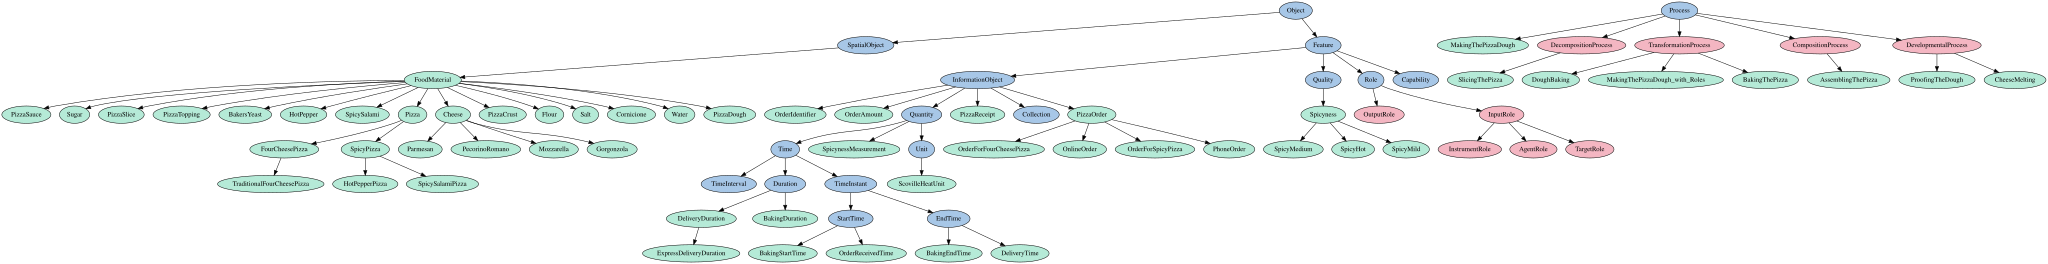

In [7]:
import os
os.makedirs("dist", exist_ok=True)
pizza.save(file="dist/pizza-05.owl", format="rdfxml")
print("Saved pizza-05.owl")
display(get_color_tree([sulo, se, pizza]))

---

## Exercises

### Exercise 1 — `ProofingDuration`
Define a `ProofingDuration` subclass of `sulo:Duration` representing the time the dough is left to ferment. A minimum proofing time of 60 minutes produces better flavour. Define `SlowFermentedDough` as a `PizzaDough` that has a feature of a `ProofingDuration` with `hasValue >= 60`. Run the reasoner and verify consistency.



In [8]:
# Exercise 1 — your code here


### Exercise 2 — `SameDayDelivery`
Define a `SameDayDelivery` class for pizza orders delivered within 240 minutes (4 hours) of being placed. Create an `OrderReceivedTime` individual and a `DeliveryTime` individual, then create a `DeliveryDuration` individual with a value. Use the reasoner to check if it qualifies as `SameDayDelivery`.



In [9]:
# Exercise 2 — your code here


### Exercise 3 — Complete event chain
Model a complete baking event for a `TraditionalFourCheesePizza`. Create individual time instants for all five process stages from notebook 03 (`MakingThePizzaDough` through `SlicingThePizza`) and link them with `atTime` and `precedes`. Run the reasoner and verify the chain is consistent.



In [10]:
# Exercise 3 — your code here
